
# **Case Study – Walmart**


---
 <p style="line-height: 2;">
<h5><div align="justify">
The Management team at Walmart Inc. wants to analyse the customer purchase
behaviour (specifically, purchase amount) against the customer’s gender
and the various other factors to help the business make better  decisions. They want to understand if the spending habits differ between    male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).


As a data analyst/scientist at Walmart, you have been  assigned   the responsibility of examining the provided dataset to derive meaningful insights and provide actionable recommendations.




<br> <br>

1. Importing the data and usual analysis.
<br><br>

> a. Data types present in the dataset.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

wm=pd.read_csv("/content/walmart_data.csv")
wm.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
wm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
wm['Product_Category']=wm['Product_Category'].astype('str')
wm['User_ID']=wm['User_ID'].astype('str')
wm['Occupation']=wm['Occupation'].astype('str')






> Converting Product category and User_id columns to string for the ease of computations.



<br>


---
<br><br>

<h5>
b. What is the shape of the dataset<h5>

In [ ]:
wm.shape

(550068, 10)



> The dataset has 550068 rows and 10 columns
<br>


---

<br>



In [ ]:
wm[wm.duplicated()]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase




> The dataset do not have any duplicate rows
<br>


---





<br>c. Checking for null values.

In [ ]:
wm[wm.isna().sum(axis=1)>0]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase




> There is no missing data or null value in the dataset

<br><br>

---





In [ ]:
wm.describe()

,Marital_Status,Purchase
count,550068.000000,550068.000000
mean,0.409653,9263.968713
std,0.491770,5023.065394
min,0.000000,12.000000
25%,0.000000,5823.000000
50%,0.000000,8047.000000
75%,1.000000,12054.000000
max,1.000000,23961.000000


In [ ]:
wm.describe(include=['object', 'bool'])

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Product_Category
count,550068,550068,550068,550068,550068,550068,550068,550068
unique,5891,3631,2,7,21,3,5,20
top,1001680,P00265242,M,26-35,4,B,1,5
freq,1026,1880,414259,219587,72308,231173,193821,150933



2. Detecting  outliers and count of each column.
<br>

    a. Outliers in column age.


<Axes: ylabel='Age'>

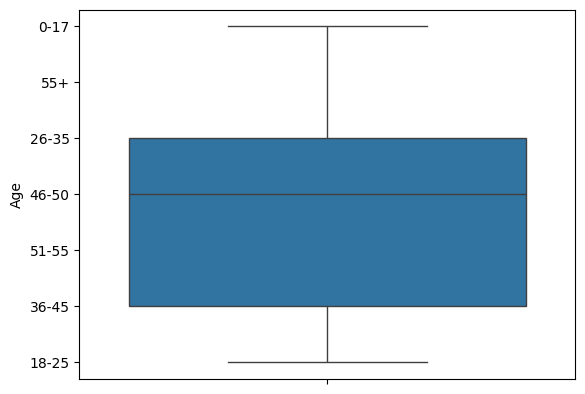

In [ ]:
sns.boxplot(data=wm, y='Age')



> There is no outlier in the column age. The median is the range of 46-50 years.
<br>
<br>








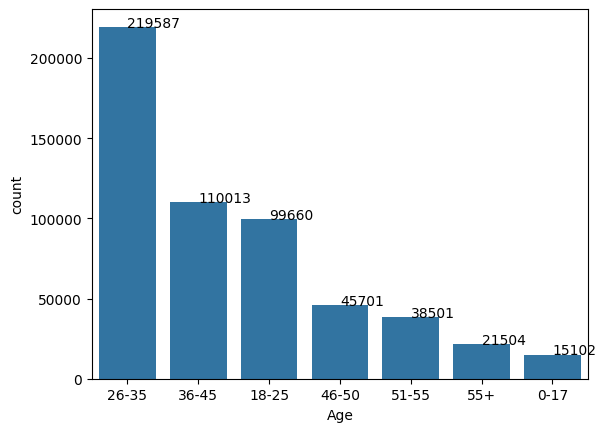

In [ ]:
agedata=wm.groupby('Age').size()
agedata=agedata.sort_values(ascending=False)
sns.countplot(data=wm, x='Age', order=agedata.index)
for index,value in enumerate(agedata):
  plt.text(index,value,value)

([<matplotlib.patches.Wedge at 0x7de8b593d8a0>,
 [Text(0.34254781550769436, 1.0453042590991901, '26-35'),
  Text(-1.0999860751865844, 0.005534834741354073, '36-45'),
  Text(-0.406302589631829, -1.0222124073099825, '18-25'),
  Text(0.48031423239356413, -0.9895949869316142, '46-50'),
  Text(0.8836014705420766, -0.655170543641791, '51-55'),
  Text(1.0523803112495336, -0.32014946586607823, '55+'),
  Text(1.0959108835259952, -0.09475935504884372, '0-17')],
 [Text(0.1868442630041969, 0.5701659595086491, '39.9%'),
  Text(-0.5999924046472278, 0.0030190007680113125, '20.0%'),
  Text(-0.221619594344634, -0.5575704039872632, '18.1%'),
  Text(0.2619895813055804, -0.5397790837808804, '8.3%'),
  Text(0.48196443847749626, -0.3573657510773405, '7.0%'),
  Text(0.5740256243179273, -0.17462698138149718, '3.9%'),
  Text(0.597769572832361, -0.05168692093573293, '2.7%')])

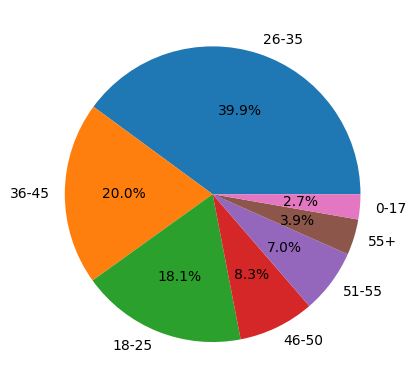

In [ ]:
plt.pie(x=agedata,labels=agedata.index,autopct='%1.1f%%')



>  Age group of 26 to 35 have made almost 40%  of all the purchases followed by 36 to 45 age group . Least purchases are made by age group of upto 17 years.





  <br>


---


<br>



   b. Outliers in the column occupation.

<Axes: ylabel='Occupation'>

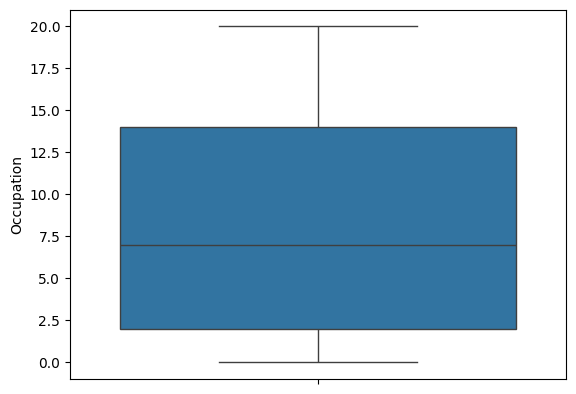

In [ ]:
sns.boxplot(data=wm, y='Occupation')



> Column occupation is also not having any outliers.



In [ ]:
occdata=wm.groupby('Occupation').size()
occdata=occdata.sort_values(ascending=False)
occdata

Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
dtype: int64



  

> The occupation names are masked using numbers. The occupation number 4 is having highest number of customers. Least customers are from occupation no: 8





<br>


---



  <h5><br>
  c. Count of values in in column City Category.


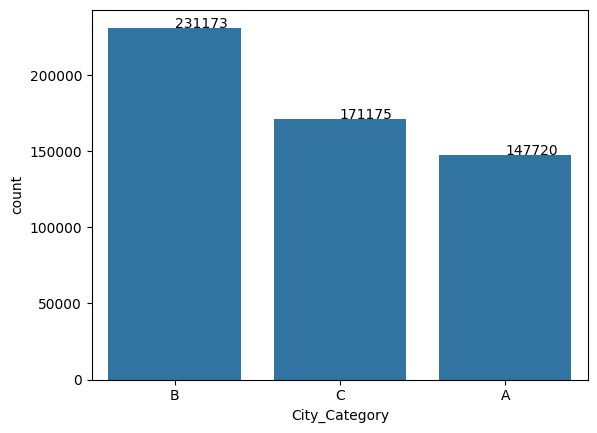

In [ ]:
citydata=wm.groupby('City_Category').size()
citydata=citydata.sort_values(ascending=False)
sns.countplot(data=wm, x='City_Category', order=citydata.index)
for index,value in enumerate(citydata):
  plt.text(index,value,value)

([<matplotlib.patches.Wedge at 0x7de8b52694e0>,
 [Text(0.27267989579948126, 1.0656667745720443, 'B'),
  Text(-0.9774040218269879, -0.5046596656326213, 'C'),
  Text(0.7311976184733743, -0.8217968378734892, 'A')],
 [Text(0.14873448861789884, 0.5812727861302059, '42.0%'),
  Text(-0.5331294664510843, -0.27526890852688435, '31.1%'),
  Text(0.3988350646218405, -0.4482528206582668, '26.9%')])

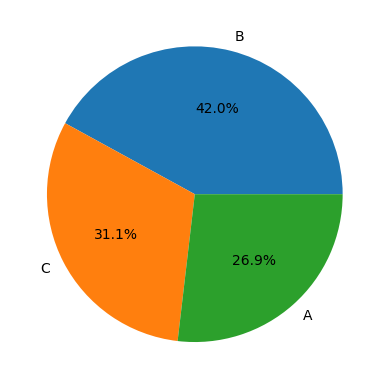

In [ ]:
plt.pie(x=citydata,labels=citydata.index,autopct='%1.1f%%')



> <h5>A large margin of customers are from city category B (42 %). City category A has least number of customers.
<br><br>


---





<br><br>
d. Outliers and count of values in column Stay_In_Current_City_Years

<Axes: ylabel='Stay_In_Current_City_Years'>

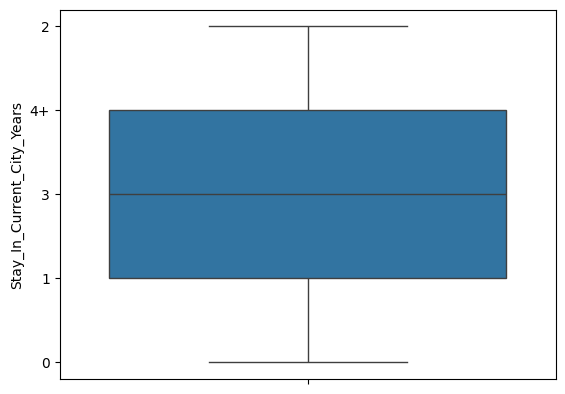

In [ ]:
sns.boxplot(data=wm, y='Stay_In_Current_City_Years')



> The column is not having any outliers.



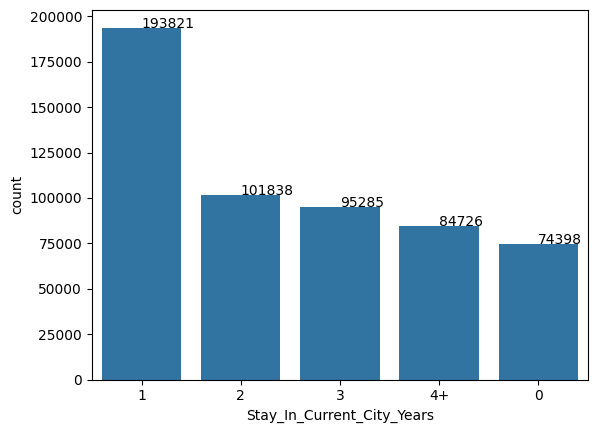

In [ ]:
staydata=wm.groupby('Stay_In_Current_City_Years').size()
staydata=staydata.sort_values(ascending=False)
sns.countplot(data=wm, x='Stay_In_Current_City_Years', order=staydata.index)
for index,value in enumerate(staydata):
  plt.text(index,value,value)

([<matplotlib.patches.Wedge at 0x7de8b5227c10>,
 [Text(0.4921146236045687, 0.983780055314466, '1'),
  Text(-1.0347973749789408, 0.37308764752628026, '2'),
  Text(-0.7821676107334653, -0.7734428412749725, '3'),
  Text(0.2583588870847174, -1.0692290145073442, '4+'),
  Text(1.002184351502242, -0.4534606108627638, '0')],
 [Text(0.2684261583297647, 0.5366073028987995, '35.2%'),
  Text(-0.5644349318066949, 0.20350235319615284, '18.5%'),
  Text(-0.4266368785818901, -0.42187791342271225, '17.3%'),
  Text(0.14092302931893672, -0.583215826094915, '15.4%'),
  Text(0.5466460099103138, -0.24734215137968932, '13.5%')])

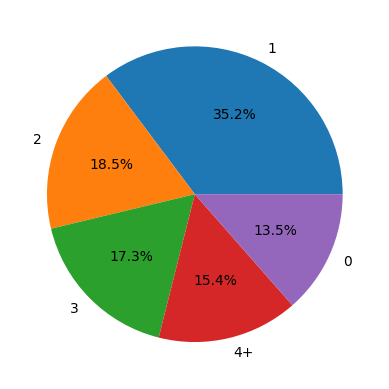

In [ ]:
plt.pie(x=staydata,labels=staydata.index,autopct='%1.1f%%')


<h5><div align="justify">
<ul>

<li>35% of the customers in the dataset have stayed in their current city only for a year. This may be because the customers are students or young professionals.

<li>All the other categories have lessthan 20% customers.

<li>We can also see low count for customers who have stayed in their city for more than 4 years and less than a year.

<br><br>



---





<br>
<h5>
e. Count of column Marital Status

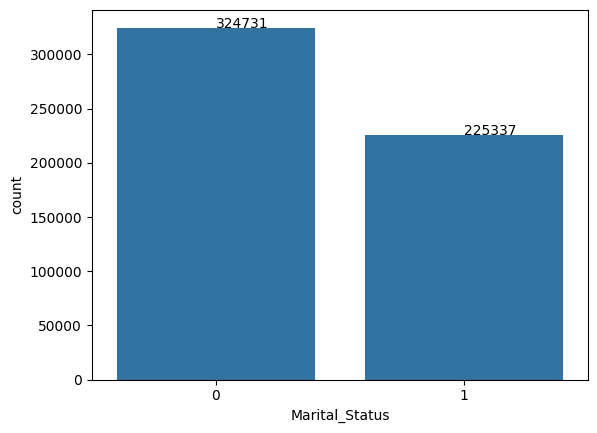

In [ ]:
mardata=wm.groupby('Marital_Status').size()
mardata=mardata.sort_values(ascending=False)
sns.countplot(data=wm, x='Marital_Status', order=mardata.index)
for index,value in enumerate(mardata):
  plt.text(index,value,value)

([<matplotlib.patches.Wedge at 0x7de8b1889990>,
 [Text(-0.3080415398264776, 1.0559878833307383, '0'),
  Text(0.30804144095775543, -1.055987912171664, '1')],
 [Text(-0.16802265808716957, 0.5759933909076753, '59.0%'),
  Text(0.16802260415877565, -0.5759934066390894, '41.0%')])

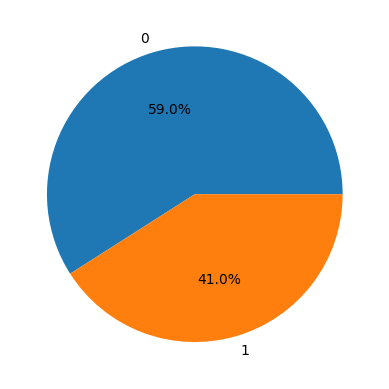

In [ ]:
plt.pie(x=mardata,labels=mardata.index,autopct='%1.1f%%')



> Almost 60% of walmart  customers  are unmarried.
<br><br>


---




<br><h5>
f. Count of values in Product Category.

In [ ]:
prdctdata=wm.groupby('Product_Category').size()
prdctdata=prdctdata.sort_values(ascending=False)
prdctdata

Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
dtype: int64

([<matplotlib.patches.Wedge at 0x7de8b1788e80>,
 [Text(0.7159952330593233, 0.8350753416526712, '5'),
  Text(-0.897934430599324, 0.6353847325394814, '1'),
  Text(-0.7370040328598891, -0.8165935681526395, '8'),
  Text(0.06063841555599795, -1.0983273567378982, '11'),
  Text(0.35661139538427433, -1.040590367379057, '2'),
  Text(0.605894965855439, -0.9180911122274502, '6'),
  Text(0.8010018928307994, -0.7539203987699741, '3'),
  Text(0.9245674682849536, -0.5959656001726539, '4'),
  Text(0.9908233972636981, -0.4777750468942726, '16'),
  Text(1.0305474484438566, -0.3846712317107386, '15'),
  Text(1.054182622392725, -0.3141639677703304, '13'),
  Text(1.071364620775545, -0.24935486630597928, '10'),
  Text(1.0828408495951083, -0.19353473705809018, '12'),
  Text(1.0902755831416036, -0.14594229272296746, '7'),
  Text(1.0951471077472266, -0.10321246239134498, '18'),
  Text(1.097916615311446, -0.06766909060316025, '20'),
  Text(1.0992126812980787, -0.04161107152536206, '19'),
  Text(1.09978036331608

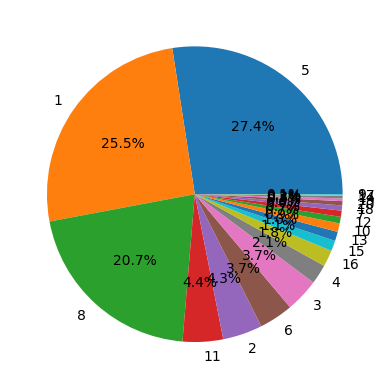

In [ ]:
plt.pie(x=prdctdata,labels=prdctdata.index,autopct='%1.1f%%')





*   Product Categories 5,1 and 8 are having huge number of customers (more than 20% for each).


*   All the other categories togather comprises of only 26.4%.


*   Least number of customers are for Product Categories 17 and 9.

<br>


---







<br>
g. Count of customers in column Gender.

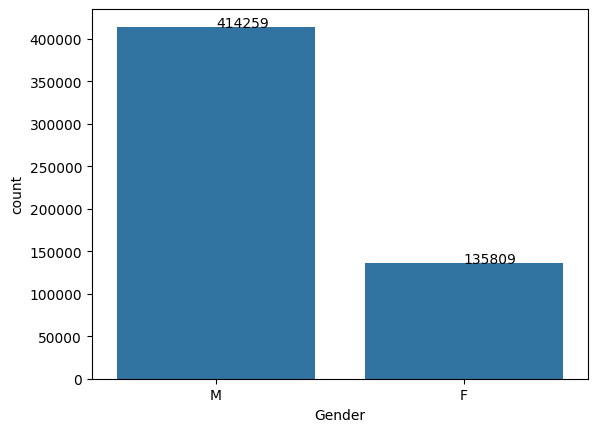

In [ ]:
gendrdata=wm.groupby('Gender').size()
gendrdata=gendrdata.sort_values(ascending=False)
sns.countplot(data=wm, x='Gender', order=gendrdata.index)
for index,value in enumerate(gendrdata):
  plt.text(index,value,value)

([<matplotlib.patches.Wedge at 0x7c8cba3842b0>,
 [Text(-0.785367774085001, 0.7701931312526561, 'M'),
  Text(0.7853677019743126, -0.7701932047840901, 'F')],
 [Text(-0.42838242222818235, 0.42010534431963054, '75.3%'),
  Text(0.42838238289507957, -0.42010538442768547, '24.7%')])

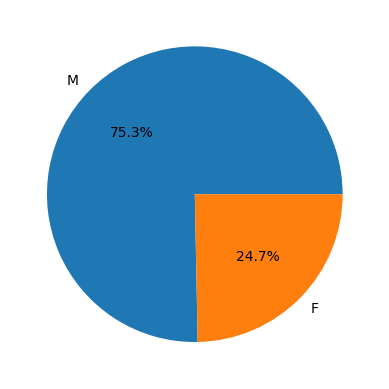

In [ ]:
plt.pie(x=gendrdata,labels=gendrdata.index,autopct='%1.1f%%')

<h5><ul>75% of customers for Walmart are male.
<br><br>

---






<br><h5>
h. Outliers and distribution of the column Purchase

<Axes: ylabel='Purchase'>

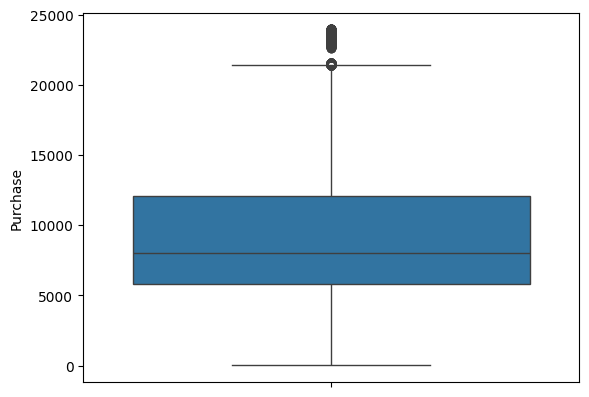

In [ ]:
sns.boxplot(data=wm, y='Purchase')



> We can see many outliers for the column Purchase which lie between the range of 20000 to 25000.



In [ ]:
fifth_perc = wm['Purchase'].quantile(0.05)
ninetyfifth_perc = wm['Purchase'].quantile(0.95)
wm['Purchase'] = np.clip(wm['Purchase'], fifth_perc, ninetyfifth_perc)



> The above code is used to clip the Purchase values and bring them to a limit of 5 to 95 percentile of the column values.



In [ ]:
wm.Purchase.describe()

count    550068.000000
mean       9256.710489
std        4855.947166
min        1984.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       19336.000000
Name: Purchase, dtype: float64

<Axes: xlabel='Purchase', ylabel='Count'>

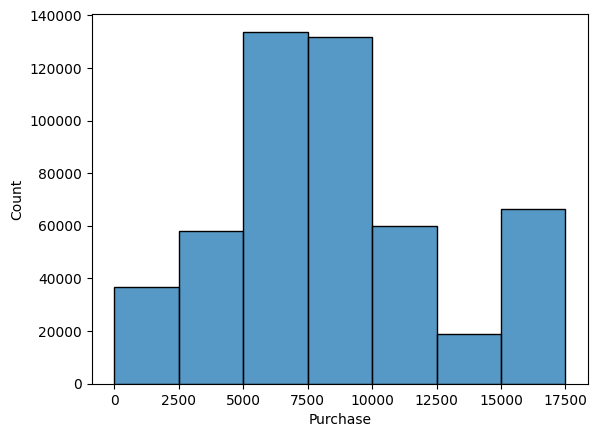

In [ ]:
bins=np.arange(0,20000,2500)
sns.histplot(wm['Purchase'],bins=bins)





*   Most purchases are between the range of 5000 to 10000.
*   We can see a dip in purchases in the range 12500 to 15000 surge in purchases at the range of 15000 to 17500.

<br><br>


---







<br>

3. Data Exploration.
<br>

  a. How are product categories related to purchase amounts.


<Axes: xlabel='Product_Category', ylabel='Purchase'>

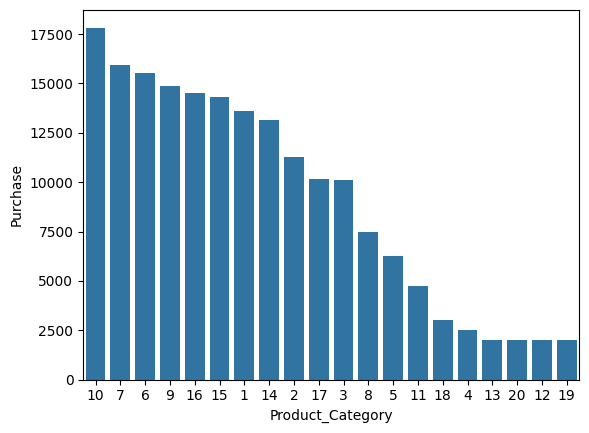

In [ ]:
Purchcat=wm.groupby('Product_Category').Purchase.mean().to_frame()
Purchcat=Purchcat.sort_values(by='Purchase',ascending=False)
sns.barplot(data=Purchcat, x='Product_Category',y='Purchase')


<h5><div align="justify">
<ul>
<li>The mean purchase amount for Product Category 10 is the highest which is more than 17500. So the products under this category must be expensive.

<li>This is followed by categories 7 and 6 which have mean purchase amounts between 15000 and 17500.

<li>Product categories 13, 20, 12 and 19 have very low mean purchase amount which is less than 2500.

<br><br>


---







<br><h5>
b. What products are different age groups buying?

<Axes: xlabel='Age', ylabel='Product_Category'>

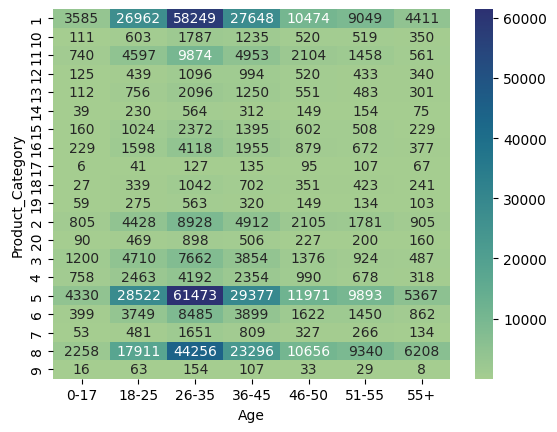

In [ ]:
pivot_table = wm.pivot_table(index='Product_Category', columns='Age', aggfunc='size', fill_value=0)

sns.heatmap(pivot_table, annot=True,fmt="d",cmap='crest')


<h5><div align="justify">
<ul>
<li> Products under Category 5 is the most popular product for customers in age of upto 55 years. Category 8 is popular among people above the age of 55.
<li>Product 1 and 8 are second and third popular products among age of upto 55. Category 5 and 1 are the second and third most popular products among customers of age above 55.
<li>Most of the other Product categories have number of purchases below 10000 in the dataset.
<li>Categories 17, 9 and 14 are least popular among all age group.



In [ ]:
agecrstab=pd.crosstab(wm.Product_Category,wm.Age,margins=True)
ageprob=agecrstab.div(agecrstab['All'],axis=0)
ageprob

Age,0-17,18-25,26-35,36-45,46-50,51-55,55+,All
Product_Category,,,,,,,,
1,0.025538,0.192067,0.414944,0.196954,0.074613,0.064462,0.031422,1.0
10,0.021659,0.117659,0.348683,0.240976,0.101463,0.101268,0.068293,1.0
11,0.030469,0.189278,0.406555,0.203936,0.086631,0.060032,0.023099,1.0
12,0.031670,0.111224,0.277679,0.251837,0.131746,0.109704,0.086141,1.0
13,0.020184,0.136241,0.377726,0.225266,0.099297,0.087043,0.054244,1.0
14,0.025607,0.151018,0.370322,0.204859,0.097833,0.101116,0.049245,1.0
15,0.025437,0.162798,0.377107,0.221781,0.095707,0.080763,0.036407,1.0
16,0.023301,0.162597,0.419007,0.198921,0.089438,0.068376,0.038360,1.0
17,0.010381,0.070934,0.219723,0.233564,0.164360,0.185121,0.115917,1.0


<h5><div align="justify">
The above crosstab shows given that customer bought the mentioned product, the probability of them belonging to the particular age group.

<ul>
<li>All the products have maximum customers in the age group of 26-35.
<li>This is followed by age group of 36-45 and 18-25.

<br><br>


---






<br><h5>
c. Is there a relationship between age, marital status, and the amount spent?

<Axes: xlabel='Marital_Status', ylabel='Age'>

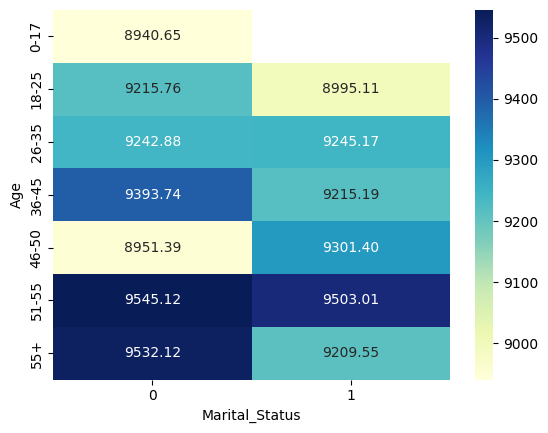

In [ ]:
agemarpivot=wm.pivot_table(index='Age',columns='Marital_Status',values='Purchase', aggfunc='mean')
sns.heatmap(agemarpivot, annot=True, cmap="YlGnBu",fmt='.2f')

<h5><div align="justify">
The above heatmap shows the mean amount spent by a customer belonging to a certain age group who are married/unmarried.

<ul>
<li>Unmarried customers above the age of 50 have highest mean amount spent followed by married customers of age group 51-55.
<li>Lowest mean spending is of age group of upto 17 years and unmarried people of age group 46 to 50 and married people of age 18-25.
<li>All the other age groups married and unmarried have almost similar mean spending habits even though there is a small surge in spending of unmarried customers of age 36 to 45.

<Axes: xlabel='Marital_Status', ylabel='Age'>

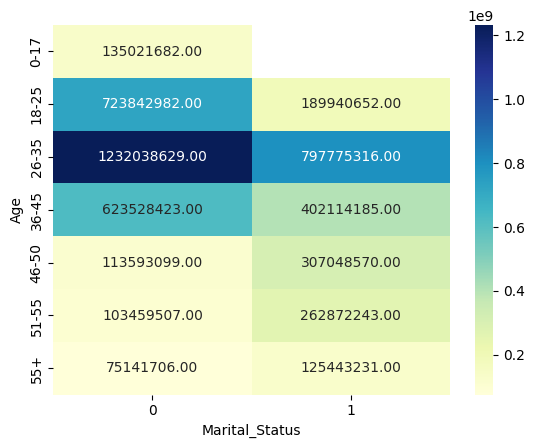

In [ ]:
agemarpivot=wm.pivot_table(index='Age',columns='Marital_Status',values='Purchase', aggfunc='sum')
sns.heatmap(agemarpivot, annot=True, cmap="YlGnBu",fmt='.2f')

<h5><div align="justify">




The above heatmap shows the sum of amount spent by customers belonging to a certain age group who are married/unmarried.

<ul>
<li> The maximum amount is spent by unmarried customers of age 26-35 by a large margin.
<li>For customers of age upto 45 years, unmarried people have spent more Purchase amount in total.This may be because there are more unmarried people in the age group.
<li>From age above 46 years, married people have spent more amount in total.

<br><br>


---





<br><h5>
d. Are there preferred product categories for different genders?

<Axes: xlabel='Product_Category', ylabel='count'>

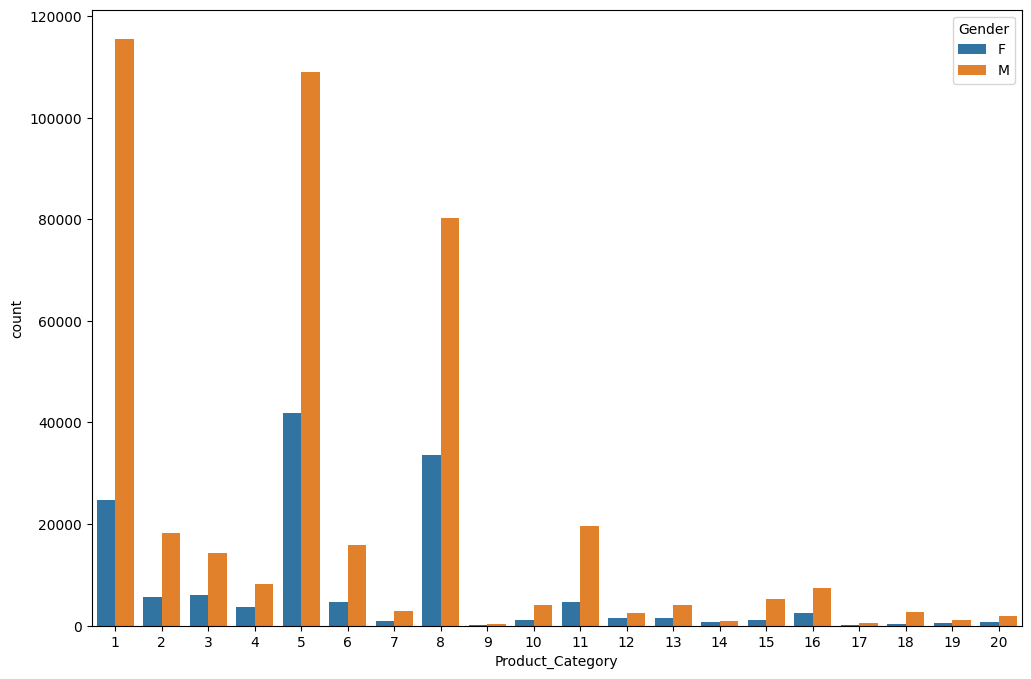

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(x='Product_Category',hue='Gender',data=wm)

<h5><div align="justify">
<ul>
<li>Male customers very highly prefer the products 1,5 and 8.
<li>Female customers also mostly opt for these 3 products but number of female customers for the products is much less than the male customers.

In [ ]:
gendrcrstab=pd.crosstab(wm.Product_Category,wm.Gender,margins=True)
gendrprob=gendrcrstab.div(gendrcrstab['All'],axis=0)
gendrprob

Gender,F,M,All
Product_Category,,,
1,0.176887,0.823113,1.0
2,0.237094,0.762906,1.0
3,0.297136,0.702864,1.0
4,0.309623,0.690377,1.0
5,0.278011,0.721989,1.0
6,0.222760,0.777240,1.0
7,0.253426,0.746574,1.0
8,0.294562,0.705438,1.0
9,0.170732,0.829268,1.0


<h5><div align="justify">
The above crosstab shows given the customer bought the particular product, what is the probability of them belonging to the gender.
<ul>
<li> For most of the products, male customers are much higher than the female customers.
<li>We can see that for product category 14, the difference between male and female customers is smaller.
<br><br>


---



<br>
<h5>
4. How does gender affect the amount spent?

In [ ]:
wm.groupby('Gender').Purchase.mean()

Gender
F    8736.540266
M    9427.240997
Name: Purchase, dtype: float64

<br><br>
<ul><b>Confidence Interval = 95%

---




Confidence Interval for entire dataset Male : (9411.5703573775, 9442.347209569753)  Female : (8712.50864278956, 8760.899750483348)


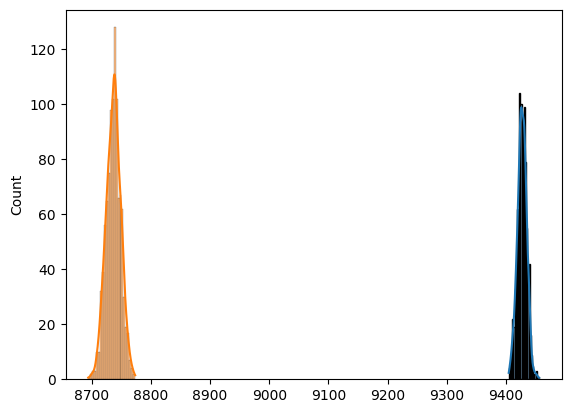

In [ ]:
def bootstrapclt(data,samplesize, ci=0.95):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    #plt.subplot(1,2,pltno)
    sns.histplot(b_means,kde=True)

    return l_limit, u_limit


ci_male_full = bootstrapclt(wm[wm.Gender=='M'].Purchase,len(wm[wm.Gender=='M'].Purchase))
ci_female_full = bootstrapclt(wm[wm.Gender=='F'].Purchase,len(wm[wm.Gender=='F'].Purchase))
print(f"Confidence Interval for entire dataset Male : {ci_male_full}  Female : {ci_female_full}")

Confidence Interval for sample size of 300 Male : (8868.965580535565, 9978.456172797767)  Female : (8209.389031797062, 9253.644434869606)


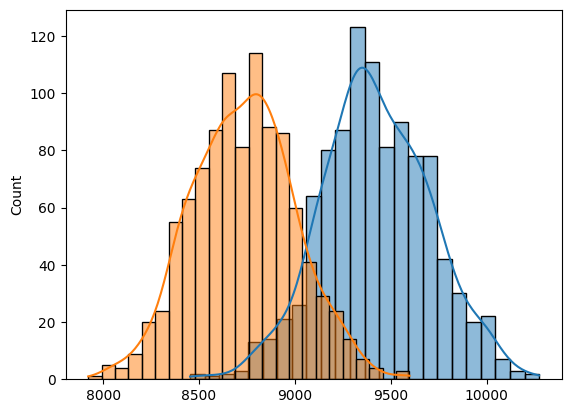

In [ ]:

male300=bootstrapclt(wm[wm.Gender=='M'].Purchase, 300)


female300=bootstrapclt(wm[wm.Gender=='F'].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Male : {male300}  Female : {female300}")

Confidence Interval for sample size of 3000 Male : (9245.323770027871, 9603.753256638794)  Female : (8575.151963894697, 8895.473886771966)


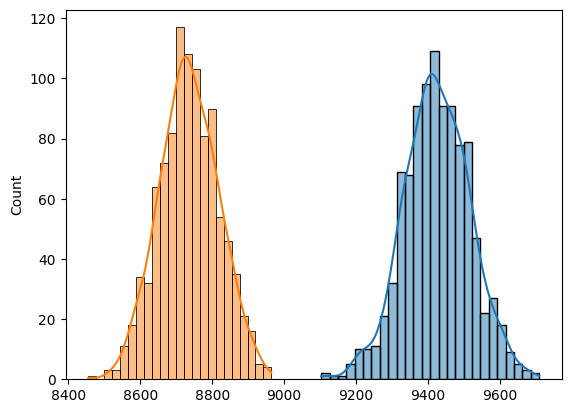

In [ ]:
male3000=bootstrapclt(wm[wm.Gender=='M'].Purchase, 3000)


female3000=bootstrapclt(wm[wm.Gender=='F'].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Male : {male3000}  Female : {female3000}")

Confidence Interval for sample size of 30000 Male : (9371.7928952716, 9481.720151995069)  Female : (8685.973615674287, 8788.040531925715)


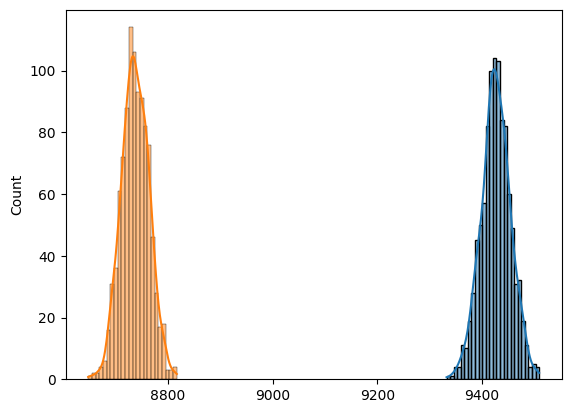

In [ ]:
male30000=bootstrapclt(wm[wm.Gender=='M'].Purchase, 30000)


female30000=bootstrapclt(wm[wm.Gender=='F'].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Male : {male30000}  Female : {female30000}")

<br><ul>
<b>Confidence Interval : 90%

---



In [ ]:
def bootstrapclt90(data,samplesize, ci=0.90):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    #plt.subplot(1,2,pltno)
    #sns.histplot(b_means,kde=True)

    return l_limit, u_limit


ci_male_full = bootstrapclt90(wm[wm.Gender=='M'].Purchase,len(wm[wm.Gender=='M'].Purchase))
ci_female_full = bootstrapclt90(wm[wm.Gender=='F'].Purchase,len(wm[wm.Gender=='F'].Purchase))
print(f"Confidence Interval for entire dataset Male : {ci_male_full}  Female : {ci_female_full}")

Confidence Interval for entire dataset Male : (9415.25901430455, 9439.656800560062)  Female : (8715.80176913812, 8756.990660524129)


<br>

In [ ]:
male300=bootstrapclt90(wm[wm.Gender=='M'].Purchase, 300)


female300=bootstrapclt90(wm[wm.Gender=='F'].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Male : {male300}  Female : {female300}")

Confidence Interval for sample size of 300 Male : (8959.534276540908, 9896.150956792426)  Female : (8286.572359940272, 9177.589360059728)


<br>

In [ ]:
male3000=bootstrapclt90(wm[wm.Gender=='M'].Purchase, 3000)


female3000=bootstrapclt90(wm[wm.Gender=='F'].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Male : {male3000}  Female : {female3000}")

Confidence Interval for sample size of 3000 Male : (9280.870350407311, 9578.258868259354)  Female : (8603.38867965717, 8876.281137676162)


<br>

In [ ]:
male30000=bootstrapclt90(wm[wm.Gender=='M'].Purchase, 30000)


female30000=bootstrapclt90(wm[wm.Gender=='F'].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Male : {male30000}  Female : {female30000}")

Confidence Interval for sample size of 30000 Male : (9381.55548307026, 9472.984851863072)  Female : (8692.354225751342, 8779.171179781993)


<br>

<br><ul>
<b>Confidence Interval : 99%

---



In [ ]:
def bootstrapclt99(data,samplesize, ci=0.99):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    #plt.subplot(1,2,pltno)
    #sns.histplot(b_means,kde=True)

    return l_limit, u_limit


ci_male_full = bootstrapclt99(wm[wm.Gender=='M'].Purchase,len(wm[wm.Gender=='M'].Purchase))
ci_female_full = bootstrapclt99(wm[wm.Gender=='F'].Purchase,len(wm[wm.Gender=='F'].Purchase))
print(f"Confidence Interval for entire dataset Male : {ci_male_full}  Female : {ci_female_full}")

Confidence Interval for entire dataset Male : (9408.176213663735, 9445.86599184538)  Female : (8704.133336884712, 8768.990365977395)


<br>

In [ ]:
male300=bootstrapclt99(wm[wm.Gender=='M'].Purchase, 300)


female300=bootstrapclt99(wm[wm.Gender=='F'].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Male : {male300}  Female : {female300}")

Confidence Interval for sample size of 300 Male : (8683.935214092337, 10175.21635257433)  Female : (8090.920642085578, 9402.689417914426)


<br>

In [ ]:
male3000=bootstrapclt99(wm[wm.Gender=='M'].Purchase, 3000)


female3000=bootstrapclt99(wm[wm.Gender=='F'].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Male : {male3000}  Female : {female3000}")

Confidence Interval for sample size of 3000 Male : (9197.587540966428, 9653.810499033572)  Female : (8524.269129771521, 8957.38570356181)


<br>

In [ ]:
male30000=bootstrapclt99(wm[wm.Gender=='M'].Purchase, 30000)


female30000=bootstrapclt99(wm[wm.Gender=='F'].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Male : {male30000}  Female : {female30000}")

Confidence Interval for sample size of 30000 Male : (9355.700942784246, 9500.24911648242)  Female : (8667.745779467572, 8807.126510665763)


<h5><div align="justify"><br>a. Is the confidence interval computed using the entire dataset wider for
one of the genders? Why is this the case?

<ul>

<h5><div align="justify">
<ul>
<li>The Confidence Interval is wider for females for the entire dataset. This is because of higher variability in the purchase amounts among females compared to males. This could be due to a greater diversity in purchasing behaviors among females, leading to a higher standard deviation.
<li>
The CI is narrower for males, suggesting less variability in their purchase amounts compared to females. This indicates that male customers have a more consistent purchasing behavior.

<br><h5>
b. How is the width of the confidence interval affected by the sample size?

<h5><div align="justify">
<ul>We can clearly see that the width of the confidence interval decreases with increase in sample sizes.
<ul>
<li>The range of confidence interval for the entire dataset was 31 for male and 48 for female customers.
<li>
For sample size of 300, the range of confidence interval was 1110 for male and 1044 for female customers.
<li>
For sample size of 3000, the range of confidence interval was 358 for male and 320 for female customers.
<li>
For sample size of 30000, the range of confidence interval was 110 for male and 103 for female customers.

<br><h5>
c. Do the confidence intervals for different sample sizes overlap?

<h5><div align="justify">
<ul>
<li>There is overlap in CI for sample size of 300 for 95,90 and 99% confidence intervals.
<li>The Confidence Interval for the sample size of 300 is overlapping bewteen the 8868 and 9253 for 95% CI.
<li>As the sample size increases, the confidence interval for male and female mean purchases diverge.
<li>The CI derived from the entire dataset is displaying a significant separation between the two genders.
<li>Overall we can concluse that there is an effect on amount spent on purchase depending on the Gender of the customer.
<br>

<br><h5>
d. How does the sample size affect the shape of the distributions of the
means.

<h5><div align="justify">
<ul>As the sample size increases, the distribution of sample means becomes more normally distributed. The width of the distribution also becomes narrower as the sample size increases.

<br><h5>
e. How do the widths of confidence intervals change with confidence levels of 90%, 95%, and 99%?

<h5><div align="justify">
<ul>
<li>With increase in confidence level, we can see an increase in the width of Confidence Interval.
<li>For 99% Confidence level, the width of CI was 37 for male and 64 for female customers.
<li>For 95% Confidence level, the width of CI was 31 for male and 47 for female customers.
<li>For 90% Confidence level, the width of CI was 24 for male and 41 for female customers.
<li>Same follows for sample sizes of 300, 3000 and 30000.

<br><br>

---



<br><h5>
5. How does Marital_Status affect the amount spent?


In [ ]:
wm.groupby('Marital_Status').Purchase.mean()

Marital_Status
0    9258.820464
1    9253.669823
Name: Purchase, dtype: float64

<br><ul>
<b>Confidence Interval : 95%

---



Confidence Interval for entire dataset Married : (9234.444977703713, 9273.546785859306)  Unmarried : (9242.924936036447, 9275.662638226559)


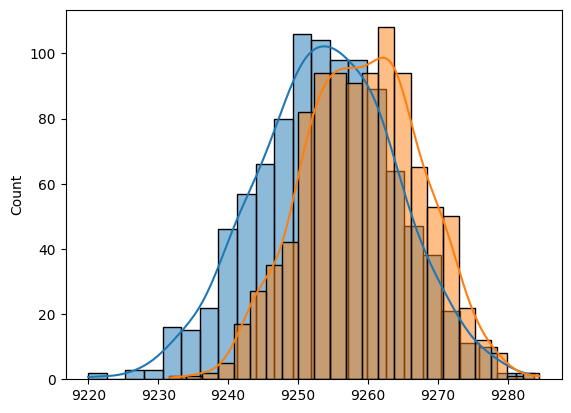

In [ ]:
ci_married_full = bootstrapclt(wm[wm.Marital_Status==1].Purchase,len(wm[wm.Marital_Status==1].Purchase))
ci_unmarried_full = bootstrapclt(wm[wm.Marital_Status==0].Purchase,len(wm[wm.Marital_Status==0].Purchase))
print(f"Confidence Interval for entire dataset Married : {ci_married_full}  Unmarried : {ci_unmarried_full}")

Confidence Interval for sample size of 300 Married : (8749.974176024449, 9795.385603975554)  Unmarried : (8735.671362993093, 9802.480257006908)


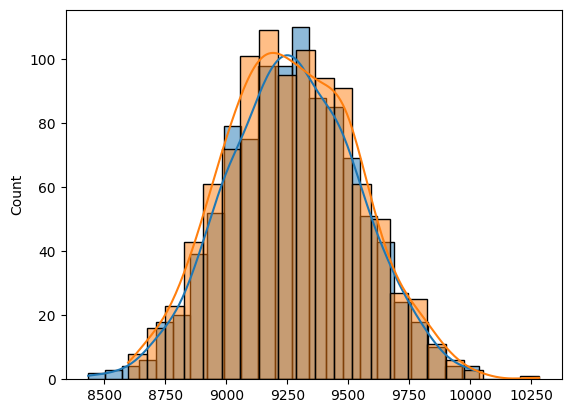

In [ ]:
Married300=bootstrapclt(wm[wm.Marital_Status==1].Purchase, 300)


Unmarried300=bootstrapclt(wm[wm.Marital_Status==0].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Married : {Married300}  Unmarried : {Unmarried300}")

Confidence Interval for sample size of 3000 Married : (9086.204883374552, 9422.949169958783)  Unmarried : (9078.354732314341, 9434.534011685659)


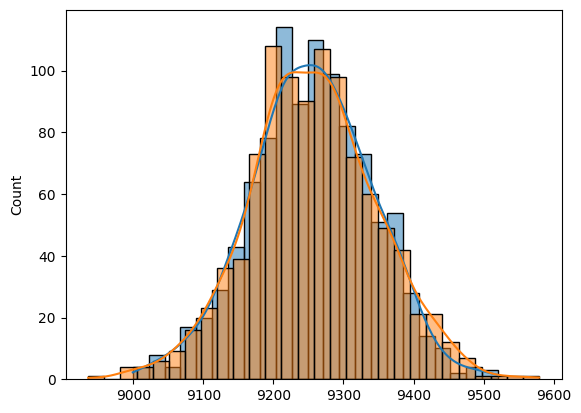

In [ ]:
Married3000=bootstrapclt(wm[wm.Marital_Status==1].Purchase, 3000)


Unmarried3000=bootstrapclt(wm[wm.Marital_Status==0].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Married : {Married3000}  Unmarried : {Unmarried3000}")

Confidence Interval for sample size of 30000 Married : (9198.109737896943, 9309.53422023639)  Unmarried : (9202.553324024371, 9311.194822642297)


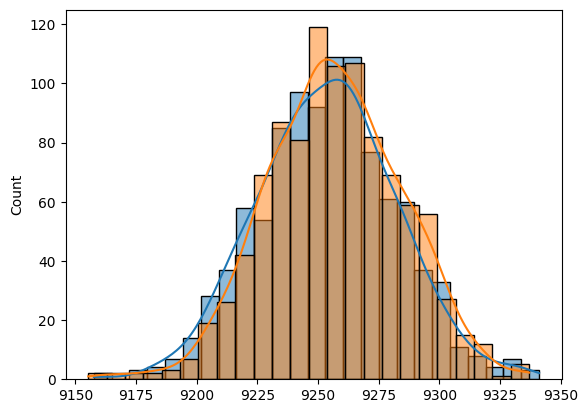

In [ ]:
Married30000=bootstrapclt(wm[wm.Marital_Status==1].Purchase, 30000)


Unmarried30000=bootstrapclt(wm[wm.Marital_Status==0].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Married : {Married30000}  Unmarried : {Unmarried30000}")

<br><ul><b>Confidence Interval : 90%

---



In [ ]:
ci_married_full = bootstrapclt90(wm[wm.Marital_Status==1].Purchase,len(wm[wm.Marital_Status==1].Purchase))
ci_unmarried_full = bootstrapclt90(wm[wm.Marital_Status==0].Purchase,len(wm[wm.Marital_Status==0].Purchase))
print(f"Confidence Interval for entire dataset Married : {ci_married_full}  Unmarried : {ci_unmarried_full}")

Confidence Interval for entire dataset Married : (9236.265647938328, 9270.592382380704)  Unmarried : (9245.763129167655, 9272.858727328956)


<br>

In [ ]:
Married300=bootstrapclt90(wm[wm.Marital_Status==1].Purchase, 300)


Unmarried300=bootstrapclt90(wm[wm.Marital_Status==0].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Married : {Married300}  Unmarried : {Unmarried300}")

Confidence Interval for sample size of 300 Married : (8783.599196329507, 9721.568650337156)  Unmarried : (8814.105821382685, 9741.006131950646)


<br>

In [ ]:
Married3000=bootstrapclt90(wm[wm.Marital_Status==1].Purchase, 3000)


Unmarried3000=bootstrapclt90(wm[wm.Marital_Status==0].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Married : {Married3000}  Unmarried : {Unmarried3000}")

Confidence Interval for sample size of 3000 Married : (9107.905417139742, 9391.641233526929)  Unmarried : (9115.350470080639, 9406.38751258603)


<br>

In [ ]:
Married30000=bootstrapclt90(wm[wm.Marital_Status==1].Purchase, 30000)


Unmarried30000=bootstrapclt90(wm[wm.Marital_Status==0].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Married : {Married30000}  Unmarried : {Unmarried30000}")

Confidence Interval for sample size of 30000 Married : (9208.533908235622, 9298.248740764378)  Unmarried : (9210.977696701315, 9303.354125565353)


<br>

<br><ul><b>Confidence Interval : 99%

---



In [ ]:
ci_married_full = bootstrapclt99(wm[wm.Marital_Status==1].Purchase,len(wm[wm.Marital_Status==1].Purchase))
ci_unmarried_full = bootstrapclt99(wm[wm.Marital_Status==0].Purchase,len(wm[wm.Marital_Status==0].Purchase))
print(f"Confidence Interval for entire dataset Married : {ci_married_full}  Unmarried : {ci_unmarried_full}")

Confidence Interval for entire dataset Married : (9228.012334647829, 9280.05317612936)  Unmarried : (9236.903442629697, 9281.397803509415)


<br>

In [ ]:
Married300=bootstrapclt99(wm[wm.Marital_Status==1].Purchase, 300)


Unmarried300=bootstrapclt99(wm[wm.Marital_Status==0].Purchase, 300)

print(f"Confidence Interval for sample size of 300 Married : {Married300}  Unmarried : {Unmarried300}")

Confidence Interval for sample size of 300 Married : (8517.159649935387, 9955.095843397947)  Unmarried : (8582.240451863026, 9950.842568136972)


<br>

In [ ]:
Married3000=bootstrapclt99(wm[wm.Marital_Status==1].Purchase, 3000)


Unmarried3000=bootstrapclt99(wm[wm.Marital_Status==0].Purchase, 3000)

print(f"Confidence Interval for sample size of 3000 Married : {Married3000}  Unmarried : {Unmarried3000}")

Confidence Interval for sample size of 3000 Married : (9023.812553405212, 9477.89812392812)  Unmarried : (9029.666506480824, 9495.354943519176)


<br>

In [ ]:
Married30000=bootstrapclt99(wm[wm.Marital_Status==1].Purchase, 30000)


Unmarried30000=bootstrapclt99(wm[wm.Marital_Status==0].Purchase, 30000)

print(f"Confidence Interval for sample size of 30000 Married : {Married30000}  Unmarried : {Unmarried30000}")

Confidence Interval for sample size of 30000 Married : (9181.508153374845, 9325.012516758488)  Unmarried : (9187.164821919225, 9329.381302747439)


<br><h5>
a. Do the confidence intervals for different sample sizes overlap?



<h5><div align="justify">
<ul>
<li>There is a considerable overlap in the confidence intervals of mean amount spent by married and unmarried customers in all the sample sizes.
<li>Highest seperation can be seen for the entire dataset sample where there is an overlap between vales of 9242 and 9273.
<li>This considerable overlap in confidence interval suggests that there is no substantial difference in the spending behaviors of married and unmarried customers.
<br>

<br><h5>
b. Is the confidence interval computed using the entire dataset wider for
one of the groups?


<h5><div align="justify">
<ul><li>For 95% confidence level, the width of CI for Married customers is 39 and unmarried customers is 32. <li>This suggests slightly more variability in the spending patterns of married customers than unmarried customers.
<li>Similar is the case for Confidence levels of 90% and 99%.
<br>

<br><h5>
c. How is the width of the confidence interval affected by the sample size.

<h5><div align="justify">
<ul>
From above calculations, we can see that as sample size increases, the confidence interval becomes narrower.
<br>

<br><h5>
d. How does the sample size affect the shape of the distributions of the
means?

<h5><div align="justify">
<ul>With increase in sample size, distribution becomes more noraml.
<br>

<br><h5>
e. How do the widths of confidence intervals change with confidence levels of 90%, 95%, and 99%?

<h5><div align="justify">
<ul>
<li>With increase in confidence level, we can see an increase in the width of Confidence Interval.
<li>For 99% Confidence level, the width of CI was 52 for married and 44 for unmarried customers.
<li>For 95% Confidence level, the width of CI was 39 for married and 32 for unmarried customers.
<li>For 90% Confidence level, the width of CI was 34 for married and 27 for unmarried customers.
<li>Same follows for sample sizes of 300, 3000 and 30000.
<br><br>


---



<br><h5>
6.  How does Age affect the amount spent?


In [ ]:
wm.groupby('Age').Purchase.mean()

Age
0-17     8940.649053
18-25    9169.010977
26-35    9243.780119
36-45    9322.921909
46-50    9204.211483
51-55    9514.863250
55+      9327.796549
Name: Purchase, dtype: float64

Confidence Interval for entire dataset 
  0-17 : (8862.312809452547, 9017.200862246564) 
 18-25 : (9139.31776093395, 9198.534778239236) 
 26-35 : (9224.520987077223, 9264.04321383631) 
 36-45 : (9293.422195882256, 9350.559988114179) 
 46-50 : (9159.60149301554, 9248.742624443596) 
 55+ : (9263.587314176675, 9392.885637739244) 


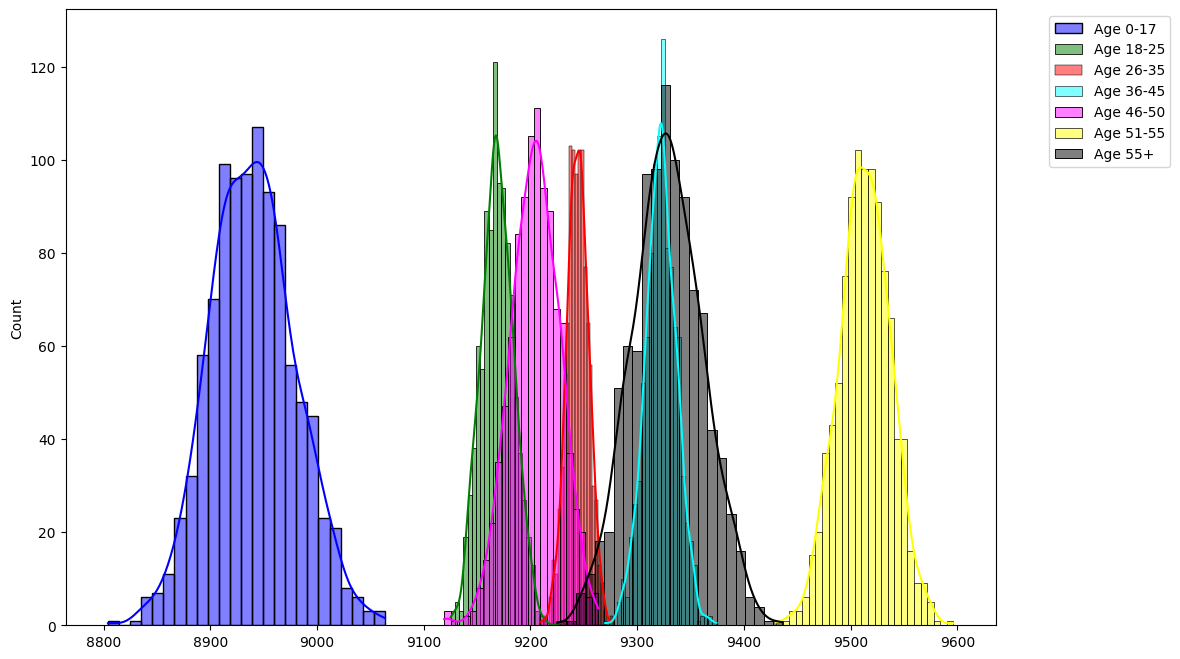

In [ ]:
def bootstrapcltage(data,samplesize,agegrp,color, ci=0.95):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    sns.histplot(b_means,kde=True,color=color, label=f"Age {agegrp}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    return l_limit, u_limit

plt.figure(figsize=(12, 8))
ci_0_17_full = bootstrapcltage(wm[wm.Age=='0-17'].Purchase,len(wm[wm.Age=='0-17'].Purchase),'0-17','blue')
ci_18_25_full = bootstrapcltage(wm[wm.Age=='18-25'].Purchase,len(wm[wm.Age=='18-25'].Purchase),'18-25','green')
ci_26_35_full = bootstrapcltage(wm[wm.Age=='26-35'].Purchase,len(wm[wm.Age=='26-35'].Purchase),'26-35','red')
ci_36_45_full = bootstrapcltage(wm[wm.Age=='36-45'].Purchase,len(wm[wm.Age=='36-45'].Purchase),'36-45','cyan')
ci_46_50_full = bootstrapcltage(wm[wm.Age=='46-50'].Purchase,len(wm[wm.Age=='46-50'].Purchase),'46-50','magenta')
ci_51_55_full = bootstrapcltage(wm[wm.Age=='51-55'].Purchase,len(wm[wm.Age=='51-55'].Purchase),'51-55','yellow')
ci_55plus_full = bootstrapcltage(wm[wm.Age=='55+'].Purchase,len(wm[wm.Age=='55+'].Purchase),'55+','black')
print(f"Confidence Interval for entire dataset \n  0-17 : {ci_0_17_full} \n 18-25 : {ci_18_25_full} \n 26-35 : {ci_26_35_full} \n 36-45 : {ci_36_45_full} \n 46-50 : {ci_46_50_full} \n 55+ : {ci_55plus_full} ")

Confidence Interval for Sample size: Entire dataset
Age group 0-17: Confidence Interval : (8862.177292551767, 9021.651830875593)
Age group 18-25: Confidence Interval : (9137.119369530332, 9200.821059729145)
Age group 26-35: Confidence Interval : (9224.551704961217, 9263.464012444638)
Age group 36-45: Confidence Interval : (9294.335526314499, 9351.171078450396)
Age group 46-50: Confidence Interval : (9160.060270698223, 9246.714168898283)
Age group 51-55: Confidence Interval : (9466.21494862803, 9566.230483750353)
Age group 55+: Confidence Interval : (9266.836640415784, 9389.59236665267)


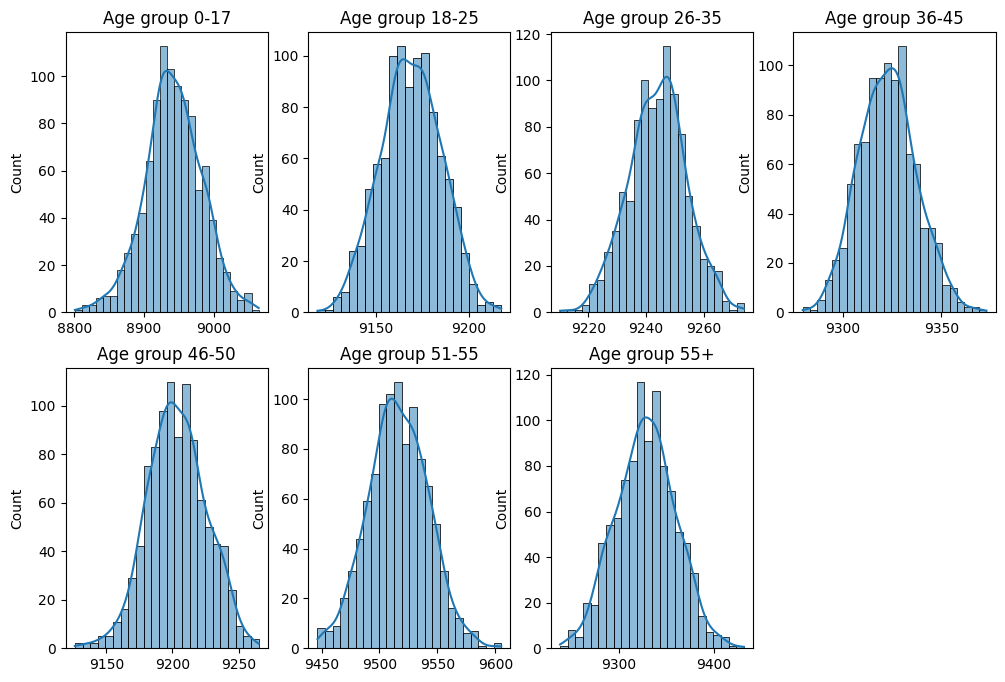

In [ ]:
def bootstrapcltagesub(data,samplesize,agegrp,pltno,color, ci=0.95):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    plt.subplot(2,4,pltno)
    plt.title(f"Age group {agegrp}")
    sns.histplot(b_means,kde=True)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    cilim=l_limit, u_limit
    print(f"Age group {agegrp}: Confidence Interval : {cilim}")
    return l_limit, u_limit

print("Confidence Interval for Sample size: Entire dataset")
plt.figure(figsize=(12, 8))
ci_0_17_full = bootstrapcltagesub(wm[wm.Age=='0-17'].Purchase,len(wm[wm.Age=='0-17'].Purchase),'0-17',1,'blue')
ci_18_25_full = bootstrapcltagesub(wm[wm.Age=='18-25'].Purchase,len(wm[wm.Age=='18-25'].Purchase),'18-25',2,'green')
ci_26_35_full = bootstrapcltagesub(wm[wm.Age=='26-35'].Purchase,len(wm[wm.Age=='26-35'].Purchase),'26-35',3,'red')
ci_36_45_full = bootstrapcltagesub(wm[wm.Age=='36-45'].Purchase,len(wm[wm.Age=='36-45'].Purchase),'36-45',4,'cyan')
ci_46_50_full = bootstrapcltagesub(wm[wm.Age=='46-50'].Purchase,len(wm[wm.Age=='46-50'].Purchase),'46-50',5,'magenta')
ci_51_55_full = bootstrapcltagesub(wm[wm.Age=='51-55'].Purchase,len(wm[wm.Age=='51-55'].Purchase),'51-55',6,'yellow')
ci_55plus_full = bootstrapcltagesub(wm[wm.Age=='55+'].Purchase,len(wm[wm.Age=='55+'].Purchase),'55+',7,'black')

#print(f"Confidence Interval for entire dataset \n  0-17 : {ci_0_17_full} \n 18-25 : {ci_18_25_full} \n 26-35 : {ci_26_35_full} \n 36-45 : {ci_36_45_full} \n 46-50 : {ci_46_50_full} \n 55+ : {ci_55plus_full} ")

 Confidenec Interval for sample size : 300
Age group 0-17: Confidence Interval : (8394.559302515541, 9499.35695748446)
Age group 18-25: Confidence Interval : (8623.74967550408, 9717.205731162589)
Age group 26-35: Confidence Interval : (8728.487282882754, 9780.622217117245)
Age group 36-45: Confidence Interval : (8775.122783801455, 9884.661696198547)
Age group 46-50: Confidence Interval : (8659.221286440728, 9748.90307355927)
Age group 51-55: Confidence Interval : (8979.358296023485, 10065.458097309845)
Age group 55+: Confidence Interval : (8781.499928544754, 9871.18732478858)


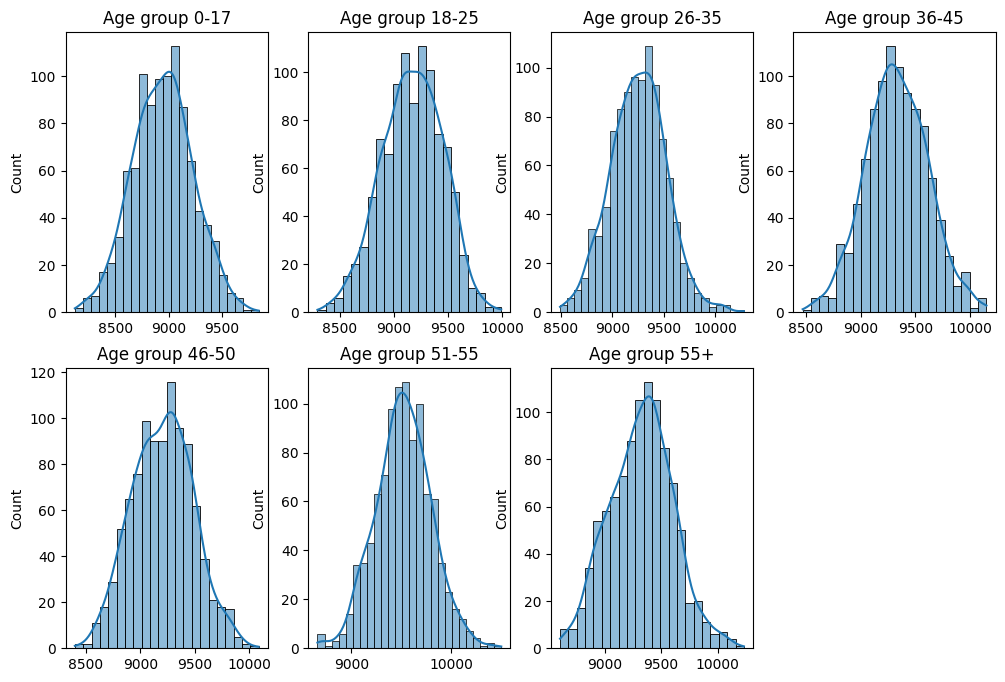

In [ ]:
print(" Confidenec Interval for sample size : 300")
plt.figure(figsize=(12, 8))
ci_0_17_300 = bootstrapcltagesub(wm[wm.Age=='0-17'].Purchase,300,'0-17',1,'blue')
ci_18_25_300 = bootstrapcltagesub(wm[wm.Age=='18-25'].Purchase,300,'18-25',2,'green')
ci_26_35_300 = bootstrapcltagesub(wm[wm.Age=='26-35'].Purchase,300,'26-35',3,'red')
ci_36_45_300 = bootstrapcltagesub(wm[wm.Age=='36-45'].Purchase,300,'36-45',4,'cyan')
ci_46_50_300 = bootstrapcltagesub(wm[wm.Age=='46-50'].Purchase,300,'46-50',5,'magenta')
ci_51_55_300 = bootstrapcltagesub(wm[wm.Age=='51-55'].Purchase,300,'51-55',6,'yellow')
ci_55plus_300 = bootstrapcltagesub(wm[wm.Age=='55+'].Purchase,300,'55+',7,'black')
#print(f"Confidence Interval for sample size of 300 \n  0-17 : {ci_0_17_300} \n 18-25 : {ci_18_25_300} \n 26-35 : {ci_26_35_300} \n 36-45 : {ci_36_45_300} \n 46-50 : {ci_46_50_300} \n 55+ : {ci_55plus_300} ")

 Confidenec Interval for sample size : 3000
Age group 0-17: Confidence Interval : (8762.1579190312, 9118.333220302135)
Age group 18-25: Confidence Interval : (8986.616709719981, 9352.075440280018)
Age group 26-35: Confidence Interval : (9070.513423868735, 9419.528714797932)
Age group 36-45: Confidence Interval : (9156.843057069076, 9494.489258930924)
Age group 46-50: Confidence Interval : (9035.641688138121, 9367.094749861879)
Age group 51-55: Confidence Interval : (9341.02763758175, 9685.098970418252)
Age group 55+: Confidence Interval : (9159.318158201275, 9497.684969798725)


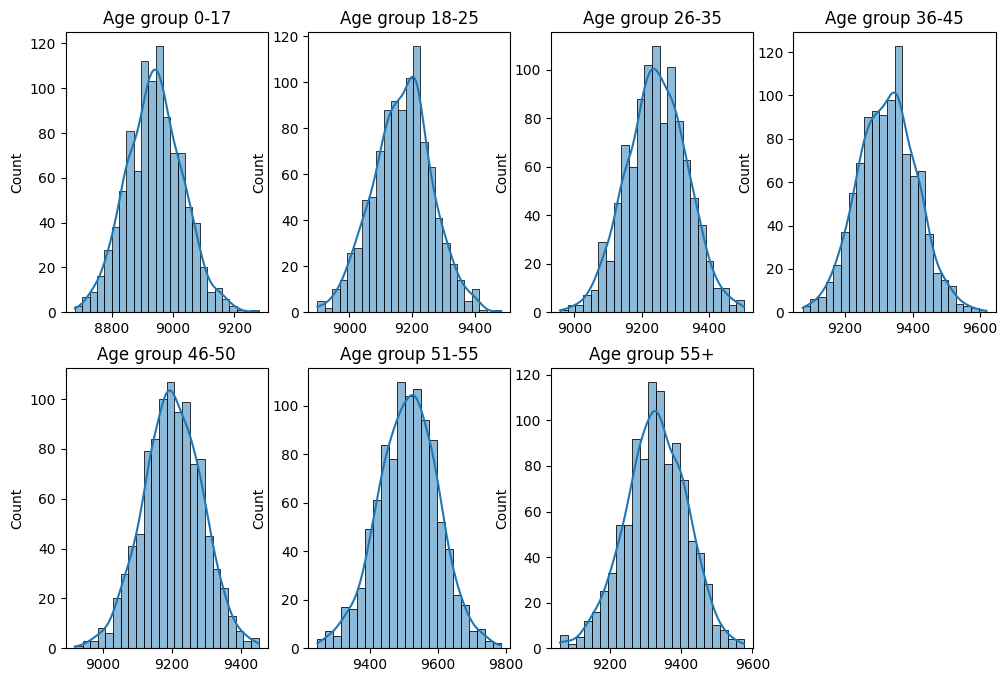

In [ ]:
print(" Confidenec Interval for sample size : 3000")
plt.figure(figsize=(12, 8))
ci_0_17_3000 = bootstrapcltagesub(wm[wm.Age=='0-17'].Purchase,3000,'0-17',1,'blue')
ci_18_25_3000 = bootstrapcltagesub(wm[wm.Age=='18-25'].Purchase,3000,'18-25',2,'green')
ci_26_35_3000 = bootstrapcltagesub(wm[wm.Age=='26-35'].Purchase,3000,'26-35',3,'red')
ci_36_45_3000 = bootstrapcltagesub(wm[wm.Age=='36-45'].Purchase,3000,'36-45',4,'cyan')
ci_46_50_3000 = bootstrapcltagesub(wm[wm.Age=='46-50'].Purchase,3000,'46-50',5,'magenta')
ci_51_55_3000 = bootstrapcltagesub(wm[wm.Age=='51-55'].Purchase,3000,'51-55',6,'yellow')
ci_55plus_3000 = bootstrapcltagesub(wm[wm.Age=='55+'].Purchase,3000,'55+',7,'black')

 Confidenec Interval for sample size : 30000
Age group 0-17: Confidence Interval : (8886.791955634044, 8995.40702996596)
Age group 18-25: Confidence Interval : (9112.657105169688, 9227.391721563643)
Age group 26-35: Confidence Interval : (9192.048832847364, 9296.850330752639)
Age group 36-45: Confidence Interval : (9268.362882320504, 9378.390000612831)
Age group 46-50: Confidence Interval : (9147.172959572143, 9260.390327894524)
Age group 51-55: Confidence Interval : (9462.519872447101, 9570.70722428623)
Age group 55+: Confidence Interval : (9274.673355229103, 9382.84009510423)


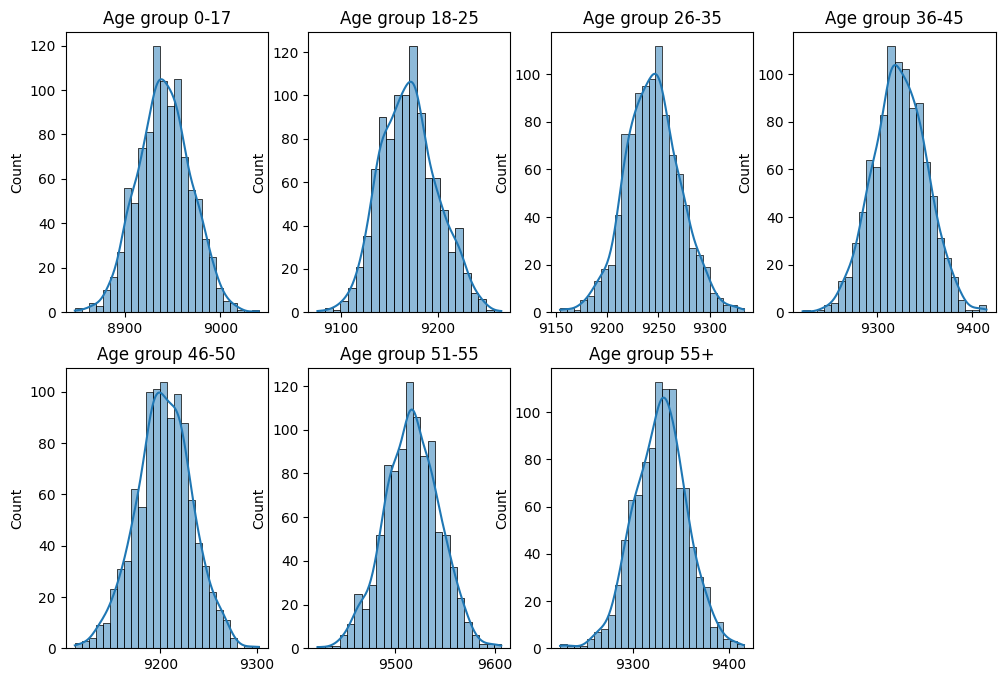

In [ ]:
print(" Confidenec Interval for sample size : 30000")
plt.figure(figsize=(12, 8))
ci_0_17_30000 = bootstrapcltagesub(wm[wm.Age=='0-17'].Purchase,30000,'0-17',1,'blue')
ci_18_25_30000 = bootstrapcltagesub(wm[wm.Age=='18-25'].Purchase,30000,'18-25',2,'green')
ci_26_35_30000 = bootstrapcltagesub(wm[wm.Age=='26-35'].Purchase,30000,'26-35',3,'red')
ci_36_45_30000 = bootstrapcltagesub(wm[wm.Age=='36-45'].Purchase,30000,'36-45',4,'cyan')
ci_46_50_30000 = bootstrapcltagesub(wm[wm.Age=='46-50'].Purchase,30000,'46-50',5,'magenta')
ci_51_55_30000 = bootstrapcltagesub(wm[wm.Age=='51-55'].Purchase,30000,'51-55',6,'yellow')
ci_55plus_30000 = bootstrapcltagesub(wm[wm.Age=='55+'].Purchase,30000,'55+',7,'black')

<br><ul><b>Confidence Interval : 90%

---



In [ ]:
def bootstrapcltagesub90(data,samplesize,agegrp,pltno,color, ci=0.90):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    #plt.subplot(2,4,pltno)
    #plt.title(f"Age group {agegrp}")
    #sns.histplot(b_means,kde=True)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    cilim=l_limit, u_limit
    print(f"Age group {agegrp}: Confidence Interval : {cilim}")
    return l_limit, u_limit

print("Confidence Interval for Sample size: Entire dataset")
#plt.figure(figsize=(12, 8))
ci_0_17_full = bootstrapcltagesub90(wm[wm.Age=='0-17'].Purchase,len(wm[wm.Age=='0-17'].Purchase),'0-17',1,'blue')
ci_18_25_full = bootstrapcltagesub90(wm[wm.Age=='18-25'].Purchase,len(wm[wm.Age=='18-25'].Purchase),'18-25',2,'green')
ci_26_35_full = bootstrapcltagesub90(wm[wm.Age=='26-35'].Purchase,len(wm[wm.Age=='26-35'].Purchase),'26-35',3,'red')
ci_36_45_full = bootstrapcltagesub90(wm[wm.Age=='36-45'].Purchase,len(wm[wm.Age=='36-45'].Purchase),'36-45',4,'cyan')
ci_46_50_full = bootstrapcltagesub90(wm[wm.Age=='46-50'].Purchase,len(wm[wm.Age=='46-50'].Purchase),'46-50',5,'magenta')
ci_51_55_full = bootstrapcltagesub90(wm[wm.Age=='51-55'].Purchase,len(wm[wm.Age=='51-55'].Purchase),'51-55',6,'yellow')
ci_55plus_full = bootstrapcltagesub90(wm[wm.Age=='55+'].Purchase,len(wm[wm.Age=='55+'].Purchase),'55+',7,'black')

Confidence Interval for Sample size: Entire dataset
Age group 0-17: Confidence Interval : (8870.357282488483, 9008.291153877562)
Age group 18-25: Confidence Interval : (9144.058196922195, 9195.16045138204)
Age group 26-35: Confidence Interval : (9227.447089810215, 9260.58176050424)
Age group 36-45: Confidence Interval : (9299.03674730635, 9346.18410132063)
Age group 46-50: Confidence Interval : (9167.121833257608, 9242.69596381466)
Age group 51-55: Confidence Interval : (9473.764237742485, 9555.642893085285)
Age group 55+: Confidence Interval : (9274.683648333359, 9380.265999081073)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 300")
#plt.figure(figsize=(12, 8))
ci_0_17_300 = bootstrapcltagesub90(wm[wm.Age=='0-17'].Purchase,300,'0-17',1,'blue')
ci_18_25_300 = bootstrapcltagesub90(wm[wm.Age=='18-25'].Purchase,300,'18-25',2,'green')
ci_26_35_300 = bootstrapcltagesub90(wm[wm.Age=='26-35'].Purchase,300,'26-35',3,'red')
ci_36_45_300 = bootstrapcltagesub90(wm[wm.Age=='36-45'].Purchase,300,'36-45',4,'cyan')
ci_46_50_300 = bootstrapcltagesub90(wm[wm.Age=='46-50'].Purchase,300,'46-50',5,'magenta')
ci_51_55_300 = bootstrapcltagesub90(wm[wm.Age=='51-55'].Purchase,300,'51-55',6,'yellow')
ci_55plus_300 = bootstrapcltagesub90(wm[wm.Age=='55+'].Purchase,300,'55+',7,'black')

 Confidenec Interval for sample size : 300
Age group 0-17: Confidence Interval : (8456.341390306185, 9398.294769693814)
Age group 18-25: Confidence Interval : (8709.855156904807, 9631.224369761858)
Age group 26-35: Confidence Interval : (8784.696805880476, 9684.869634119523)
Age group 36-45: Confidence Interval : (8860.217501293322, 9772.341545373343)
Age group 46-50: Confidence Interval : (8750.019448102239, 9659.913445231092)
Age group 51-55: Confidence Interval : (9069.762333091638, 9968.016973575026)
Age group 55+: Confidence Interval : (8863.644351128505, 9792.564575538161)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 3000")
#plt.figure(figsize=(12, 8))
ci_0_17_3000 = bootstrapcltagesub90(wm[wm.Age=='0-17'].Purchase,3000,'0-17',1,'blue')
ci_18_25_3000 = bootstrapcltagesub90(wm[wm.Age=='18-25'].Purchase,3000,'18-25',2,'green')
ci_26_35_3000 = bootstrapcltagesub90(wm[wm.Age=='26-35'].Purchase,3000,'26-35',3,'red')
ci_36_45_3000 = bootstrapcltagesub90(wm[wm.Age=='36-45'].Purchase,3000,'36-45',4,'cyan')
ci_46_50_3000 = bootstrapcltagesub90(wm[wm.Age=='46-50'].Purchase,3000,'46-50',5,'magenta')
ci_51_55_3000 = bootstrapcltagesub90(wm[wm.Age=='51-55'].Purchase,3000,'51-55',6,'yellow')
ci_55plus_3000 = bootstrapcltagesub90(wm[wm.Age=='55+'].Purchase,3000,'55+',7,'black')

 Confidenec Interval for sample size : 3000
Age group 0-17: Confidence Interval : (8791.76697693035, 9087.060151736314)
Age group 18-25: Confidence Interval : (9016.781016426052, 9315.567391573946)
Age group 26-35: Confidence Interval : (9101.883329212435, 9391.442818120902)
Age group 36-45: Confidence Interval : (9180.157926193633, 9467.620498473034)
Age group 46-50: Confidence Interval : (9057.970868311138, 9346.395337022193)
Age group 51-55: Confidence Interval : (9361.96600620917, 9658.365058457495)
Age group 55+: Confidence Interval : (9187.827325728325, 9472.108024271674)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 30000")
#plt.figure(figsize=(12, 8))
ci_0_17_30000 = bootstrapcltagesub90(wm[wm.Age=='0-17'].Purchase,30000,'0-17',1,'blue')
ci_18_25_30000 = bootstrapcltagesub90(wm[wm.Age=='18-25'].Purchase,30000,'18-25',2,'green')
ci_26_35_30000 = bootstrapcltagesub90(wm[wm.Age=='26-35'].Purchase,30000,'26-35',3,'red')
ci_36_45_30000 = bootstrapcltagesub90(wm[wm.Age=='36-45'].Purchase,30000,'36-45',4,'cyan')
ci_46_50_30000 = bootstrapcltagesub90(wm[wm.Age=='46-50'].Purchase,30000,'46-50',5,'magenta')
ci_51_55_30000 = bootstrapcltagesub90(wm[wm.Age=='51-55'].Purchase,30000,'51-55',6,'yellow')
ci_55plus_30000 = bootstrapcltagesub90(wm[wm.Age=='55+'].Purchase,30000,'55+',7,'black')

 Confidenec Interval for sample size : 30000
Age group 0-17: Confidence Interval : (8894.802056049162, 8990.265549884169)
Age group 18-25: Confidence Interval : (9120.657393940111, 9214.988297659891)
Age group 26-35: Confidence Interval : (9198.40073651552, 9289.126391951148)
Age group 36-45: Confidence Interval : (9277.137328512097, 9367.493942421239)
Age group 46-50: Confidence Interval : (9156.500652028464, 9249.288132038202)
Age group 51-55: Confidence Interval : (9471.532083750826, 9559.139875915836)
Age group 55+: Confidence Interval : (9282.779598543779, 9372.100741056225)


<br>

<br><ul><b>Confidence Interval : 99%

---



In [ ]:
def bootstrapcltagesub99(data,samplesize,agegrp,pltno,color, ci=0.99):

    iter=1000
    b_means = []
    for i in range(iter):
        sample = data.sample(samplesize,replace=True)
        b_means.append(np.mean(sample))
    #l_limit = np.percentile(b_means, (100-ci)/2)
    #u_limit = np.percentile(b_means, 100-(100-ci)/2)
    mean = np.mean(b_means)
    sigma = np.std(b_means)
    l_limit = norm.ppf((1-ci)/2) * sigma + mean
    u_limit = norm.ppf(ci+((1-ci)/2)) * sigma + mean
    #plt.subplot(2,4,pltno)
    #plt.title(f"Age group {agegrp}")
    #sns.histplot(b_means,kde=True)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    cilim=l_limit, u_limit
    print(f"Age group {agegrp}: Confidence Interval : {cilim}")
    return l_limit, u_limit

print("Confidence Interval for Sample size: Entire dataset")
#plt.figure(figsize=(12, 8))
ci_0_17_full = bootstrapcltagesub99(wm[wm.Age=='0-17'].Purchase,len(wm[wm.Age=='0-17'].Purchase),'0-17',1,'blue')
ci_18_25_full = bootstrapcltagesub99(wm[wm.Age=='18-25'].Purchase,len(wm[wm.Age=='18-25'].Purchase),'18-25',2,'green')
ci_26_35_full = bootstrapcltagesub99(wm[wm.Age=='26-35'].Purchase,len(wm[wm.Age=='26-35'].Purchase),'26-35',3,'red')
ci_36_45_full = bootstrapcltagesub99(wm[wm.Age=='36-45'].Purchase,len(wm[wm.Age=='36-45'].Purchase),'36-45',4,'cyan')
ci_46_50_full = bootstrapcltagesub99(wm[wm.Age=='46-50'].Purchase,len(wm[wm.Age=='46-50'].Purchase),'46-50',5,'magenta')
ci_51_55_full = bootstrapcltagesub99(wm[wm.Age=='51-55'].Purchase,len(wm[wm.Age=='51-55'].Purchase),'51-55',6,'yellow')
ci_55plus_full = bootstrapcltagesub99(wm[wm.Age=='55+'].Purchase,len(wm[wm.Age=='55+'].Purchase),'55+',7,'black')

Confidence Interval for Sample size: Entire dataset
Age group 0-17: Confidence Interval : (8832.928434782183, 9047.818850742917)
Age group 18-25: Confidence Interval : (9132.628220978335, 9206.770242015846)
Age group 26-35: Confidence Interval : (9216.059963213387, 9270.399773665393)
Age group 36-45: Confidence Interval : (9284.611699379064, 9361.384687120713)
Age group 46-50: Confidence Interval : (9146.687992008417, 9262.557437063158)
Age group 51-55: Confidence Interval : (9453.188233201528, 9575.64870895582)
Age group 55+: Confidence Interval : (9244.350097505865, 9411.03730567494)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 300")
#plt.figure(figsize=(12, 8))
ci_0_17_300 = bootstrapcltagesub99(wm[wm.Age=='0-17'].Purchase,300,'0-17',1,'blue')
ci_18_25_300 = bootstrapcltagesub99(wm[wm.Age=='18-25'].Purchase,300,'18-25',2,'green')
ci_26_35_300 = bootstrapcltagesub99(wm[wm.Age=='26-35'].Purchase,300,'26-35',3,'red')
ci_36_45_300 = bootstrapcltagesub99(wm[wm.Age=='36-45'].Purchase,300,'36-45',4,'cyan')
ci_46_50_300 = bootstrapcltagesub99(wm[wm.Age=='46-50'].Purchase,300,'46-50',5,'magenta')
ci_51_55_300 = bootstrapcltagesub99(wm[wm.Age=='51-55'].Purchase,300,'51-55',6,'yellow')
ci_55plus_300 = bootstrapcltagesub99(wm[wm.Age=='55+'].Purchase,300,'55+',7,'black')

 Confidenec Interval for sample size : 300
Age group 0-17: Confidence Interval : (8235.856894887827, 9660.450565112173)
Age group 18-25: Confidence Interval : (8455.351759590721, 9875.33340040928)
Age group 26-35: Confidence Interval : (8556.308395132048, 9958.026078201285)
Age group 36-45: Confidence Interval : (8581.901218883257, 10061.943314450076)
Age group 46-50: Confidence Interval : (8528.081075802738, 9882.600824197261)
Age group 51-55: Confidence Interval : (8803.928472065452, 10231.929027934546)
Age group 55+: Confidence Interval : (8618.370880571678, 10032.235059428323)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 3000")
#plt.figure(figsize=(12, 8))
ci_0_17_3000 = bootstrapcltagesub99(wm[wm.Age=='0-17'].Purchase,3000,'0-17',1,'blue')
ci_18_25_3000 = bootstrapcltagesub99(wm[wm.Age=='18-25'].Purchase,3000,'18-25',2,'green')
ci_26_35_3000 = bootstrapcltagesub99(wm[wm.Age=='26-35'].Purchase,3000,'26-35',3,'red')
ci_36_45_3000 = bootstrapcltagesub99(wm[wm.Age=='36-45'].Purchase,3000,'36-45',4,'cyan')
ci_46_50_3000 = bootstrapcltagesub99(wm[wm.Age=='46-50'].Purchase,3000,'46-50',5,'magenta')
ci_51_55_3000 = bootstrapcltagesub99(wm[wm.Age=='51-55'].Purchase,3000,'51-55',6,'yellow')
ci_55plus_3000 = bootstrapcltagesub99(wm[wm.Age=='55+'].Purchase,3000,'55+',7,'black')

 Confidenec Interval for sample size : 3000
Age group 0-17: Confidence Interval : (8697.796245505016, 9174.696645828319)
Age group 18-25: Confidence Interval : (8947.9421853283, 9407.5207506717)
Age group 26-35: Confidence Interval : (9017.94273457183, 9466.769205428167)
Age group 36-45: Confidence Interval : (9104.703395733673, 9542.84712293299)
Age group 46-50: Confidence Interval : (8992.070746567158, 9424.973980099508)
Age group 51-55: Confidence Interval : (9287.229674818791, 9742.41900184788)
Age group 55+: Confidence Interval : (9106.02879556636, 9546.462127100303)


<br>

In [ ]:
print(" Confidenec Interval for sample size : 30000")
#plt.figure(figsize=(12, 8))
ci_0_17_30000 = bootstrapcltagesub99(wm[wm.Age=='0-17'].Purchase,30000,'0-17',1,'blue')
ci_18_25_30000 = bootstrapcltagesub99(wm[wm.Age=='18-25'].Purchase,30000,'18-25',2,'green')
ci_26_35_30000 = bootstrapcltagesub99(wm[wm.Age=='26-35'].Purchase,30000,'26-35',3,'red')
ci_36_45_30000 = bootstrapcltagesub99(wm[wm.Age=='36-45'].Purchase,30000,'36-45',4,'cyan')
ci_46_50_30000 = bootstrapcltagesub99(wm[wm.Age=='46-50'].Purchase,30000,'46-50',5,'magenta')
ci_51_55_30000 = bootstrapcltagesub99(wm[wm.Age=='51-55'].Purchase,30000,'51-55',6,'yellow')
ci_55plus_30000 = bootstrapcltagesub99(wm[wm.Age=='55+'].Purchase,30000,'55+',7,'black')

 Confidenec Interval for sample size : 30000
Age group 0-17: Confidence Interval : (8868.382815591993, 9014.959088074671)
Age group 18-25: Confidence Interval : (9093.032314074135, 9241.481821325862)
Age group 26-35: Confidence Interval : (9170.20436682996, 9315.406368236705)
Age group 36-45: Confidence Interval : (9249.621279841107, 9398.138976692226)
Age group 46-50: Confidence Interval : (9133.373890933759, 9273.730633266241)
Age group 51-55: Confidence Interval : (9442.779728152833, 9585.600683113833)
Age group 55+: Confidence Interval : (9259.584309199952, 9397.895245933381)


<br><h5>
a. Is the confidence interval computed using the entire dataset wider for
any age group? Why is this the case?

<h5><div align="justify">
<ul>
<li>
For 95% confidence level, the width of CI is the largest for age group  0-17 (width is 159) followed by customers above age 55 (width is 122).
<li>The above groups show larger variability in amount spent on purchase. This may be due to more diverse ages present in these two groups.
<li>The narrowest CI is for age group of 26-35 (width is 38) followed by 36-45 (width is 56). These age groups around middle age show least variability in spending habits.
<br>



<br><h5>
b. Do the confidence intervals for different sample sizes overlap?


<h5><div align="justify">
<ul>
<li>For the entire dataset sample, there is a clear seperation for the CI for age group 0-17 (8862 to 9021) from rest of the of the age groups.
<li>CI of age group 51 to 55 is also not overlapping with any other group (9466 to 9566).
<li>We can see most of the overlapping in middle age groups.
<li>Age groups 0-17, 18-25, 26-35, and 36-45 show progressively increasing mean spending, with some overlaps but also beginning to show clear trends in spending increase with age.
<li> There is considerable overlap between mean spending of age group 46 to 50 with groups 18 to 25 and 26 to 35.
<li>Much overlap is also seen between groups 36 to 45 and 55+.
<br>

<br><h5>
c. How is the width of the confidence interval affected by the sample size?

<ul><h5>We can see decrease in width of Confidence Interval with increase in sample size.
<br>

<br><h5>
d. How is the sample size affecting the shape of the distributions of the
means?

<h5><div align="justify">
<ul>
We can see sample means becoming more normally distributed with increase in sample size.
<br>
<br><br>


---



<br><h5>
7. Check the correlation among different factors.



<ipython-input-35-4b98c9856978>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(wmcopy.corr(), annot=True, cmap='coolwarm', fmt=".2f")


<Axes: >

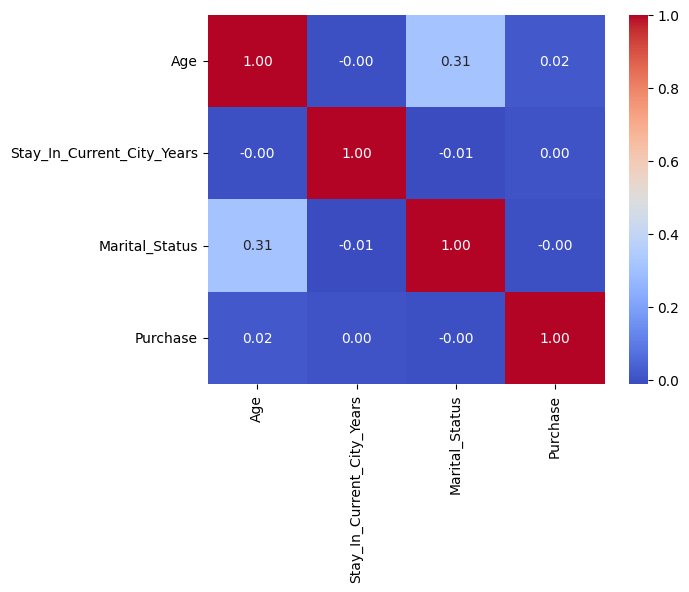

In [ ]:
wmcopy=wm
wmcopy['Stay_In_Current_City_Years']=wmcopy['Stay_In_Current_City_Years'].replace('4+','5')
wmcopy['Stay_In_Current_City_Years']=wmcopy['Stay_In_Current_City_Years'].astype('int')
wmcopy['Age']=wmcopy['Age'].replace(['0-17','18-25','26-35','36-45','46-50','51-55','55+'],['8.5','21.5','30.5','40.5','48','53','78'])
wmcopy['Age']=wmcopy['Age'].astype('float')
sns.heatmap(wmcopy.corr(), annot=True, cmap='coolwarm', fmt=".2f")

<h5><div align="justify">
<ul> Converting the columns 'Stay_In_Current_City_Years' and 'Age' to numerical values to find the correlation between different variables. Here the middle value between each age range is taken to replace the categorical column with numerical value.<ul>
<li>
Here we can see very little or no correlation between different variables.
<li>
We can see positive correlation for Marital status and age indicating married customers in the dataset are of higher age group.
<li>There is a weak positive relation between age and purchase so as age increases, there is a slight increase in amount spent on purchase.
<li>There is a weak negative relation between marital status and number of years staying in the current city.
<br>

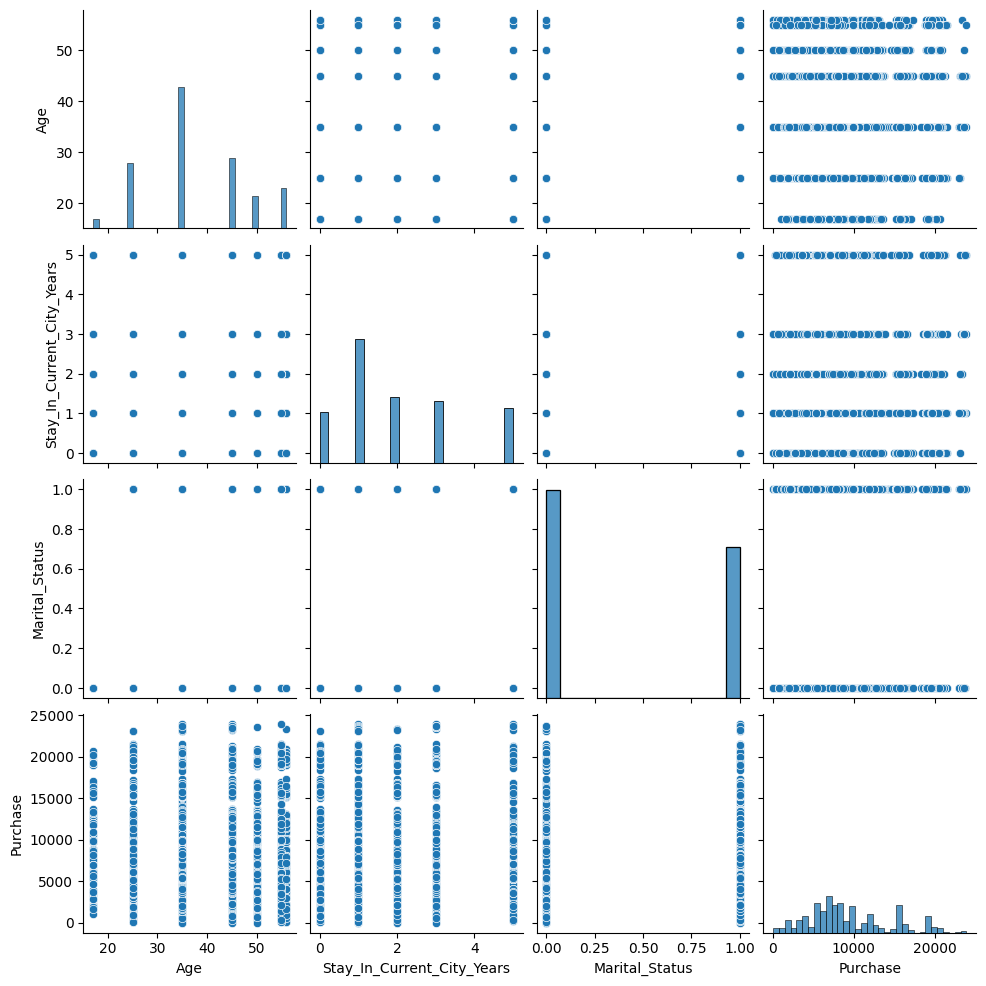

In [ ]:
sample_wm = wmcopy.sample(n=5000, random_state=1)
sns.pairplot(sample_wm)

<br><br><br>

---
<br>
<ul><h3><b>Inferences

---



<p style="line-height: 2;">
<h5><div align="justify">

<ul>
<li>75% of cutomers of Walmart are male. For most of the products, male customers are much higher than the female customers. We can see that for product category 14, the difference between male and female customers is smaller.
<br><br>

<li>Age group of 26 to 35 have made almost 40% of all the purchases followed by 36 to 45 age group . Least purchases are made by age group of upto 17 years and above 55 years.
<br><br>
 <li>The customers with occupation number 4, 0 and 7 have made highest number of purchases.
 <br><br>

<li>A large margin of customers are from city category B (42 %). City category A has least number of customers.
<br><br>

<li>35% of the customers in the dataset have stayed in their current city only for a year. This may be because the customers are students or young professionals. All the other categories have less than 20% customers.
<br><br>

<li>Almost 60% of walmart  customers  are unmarried. Unmarried customers above the age of 50 have highest mean amount spent followed by married customers of age group 51-55. Lowest mean spending is of age group of upto 17 years, unmarried people of age group 46 to 50 and married people of age 18-25.
<br><br>

<li>The maximum amount is spent by unmarried customers of age 26-35 by a large margin. We can see positive correlation for Marital status and age indicating married customers in the dataset are of higher age group.
<br><br>



<li>Product Categories 5,1 and 8 are having huge number of customers (more than 20% for each). All the other categories togather comprises of only 26.4%. Male and Female customers mostly opt for these 3 products but number of female customers for the products is much less than the male customers.
<br><br>

<li>Highest number of purchases are made between the purchase amount of 5000 to 10000.
<br><br>
<li>The most expensive products are of categories 10, 7 and 6. Product categories 13, 20, 12 and 19 have very low mean purchase amount which is less than 2500.
<br><br>

<li>Products under Category 5 is the most popular product for customers in age of upto 55 years. Category 8 is popular among people above the age of 55.
<br><BR>
All the products have maximum customers in the age group of 26-35.This is followed by age group of 36-45 and 18-25.
<br><br>

<li>The Confidence intervals for mean amount spent by male and female customers do not overlap, which indicates a significant difference in the average amount spent by males and females. This difference suggests that, on average, males spend more than females.
<br>

 The company can leverage this information to tailor marketing strategies specifically towards males and females, optimizing advertisements, promotions and recommendations to match the spending habits of each gender.
<br><br>

<li>These Confidence intervals for mean amount spent by Married and Unmarried customers overlap, indicating that there is not a  significant difference in the average amount spent by married and unmarried individuals. So marital status may not be a predictor of spending behaviour
<br><br>
Since the spending behavior between married and unmarried customers does not significantly differ, the company can consider broad marketing strategies and recommendations that appeal to both groups.
<br><br>

<li>For the Confidence intervals for mean amount spent by different age groups, there is considerable overlap between mean spending of age group 46 to 50 with groups 18 to 25 and 26 to 35.
<br><br>
Much overlap is also seen between groups 36 to 45 and 55+. Age group 0-17 and 51-55 do not overlap with any of the other groups. Age groups 51-55, 55+ and 36-45 are having highest mean spending.
<br><br>

Walmart can tailor marketing campaigns and promotions to better suit the preferences and spending habits of age groups the 51-55,36-45 and 55+ as they are having higher mean spending.

<br>
<ul><h3><b>Recommendations

---



<p style="line-height: 2;">
<h5><div align="justify">
<ul>
<li>

Since males constitute 75% of the customer base and spend more on average, Walmart should continue to focus on male-oriented marketing strategies.
<br><br>
For product category 14, where the difference between male and female customers is smaller, the company could introduce targeted marketing campaigns to further engage female customers.
The company can introduce products and increase marketing that appeal to and attract more female customers.
<br><br>
Walmart can provide discounts and other offers for female customers.
<br><br>
Since mean spending of male customers is higher, products on expensive side can be introduced and marketed
 for them.
 <br><br>

 <li>

Given that the 26-35 and 36-45 age groups constitute a significant portion of purchases, advertisements more product recommendations can cater to these age group.Product development strategies can also prioritize their interests and needs.<br><br>
For the 51-55 and 55+ age groups, which have higher mean spending but lower overall purchase numbers, premium products can be launched targeting these age groups.
<br><br>

<li>
As customers with occupations 4, 0 and 7 make largest number of purchases, new products can be introduced in the stores to cater to the needs of these customers which are useful in their work environments.
<br><br>
<li>
More number of stores or more stocks can be given to stores which are located in city category B. Localized marketing can be made stronger in city category A to attract more customers from these cities.
<br><br>
<li>
Given the lack of significant difference in spending between married and unmarried customers, marketing  should be broad enough to appeal to both segments.
<br><br>
<li>
We can ensure the stock availability on categories 5, 1, and 8, which have the highest customer interest.Special offers can also be given for them.<br><br>
For categories 10, 7, and 6, which contain the most expensive products, we can consider financing options to retain customers.
<br><br>
<li>
Since most purchases fall within the 5000 to 10000 range, Walmart should highlight products within this price range.